# Avance Proyecto Resultados 2026
## Divorcios en Guatemala — Variable respuesta, antecedentes y modelado supervisado

**CC3074 Minería de Datos | Semestre II 2026 | Universidad del Valle de Guatemala**
Integrantes: Javier Cifuentes, Ian Cumes, Javier Valladares


## 0. Dependencias

In [ ]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

SEED = 42
np.random.seed(SEED)
print('Librerías cargadas.')


## 1. Carga y limpieza del dataset

Se usa `datos_unificadosF.csv` (valores numéricos codificados). La función `norm` unifica nombres de columna eliminando acentos, mayúsculas y espacios, y `combine_first` fusiona columnas duplicadas entre años.


In [ ]:
df = pd.read_csv('datos_unificadosF.csv', low_memory=False)

def norm(s):
    s = str(s).strip().lower()
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))

normed = {c: norm(c) for c in df.columns}
clean = {}
for base in sorted(set(normed.values())):
    cols = [c for c, n in normed.items() if n == base]
    s = None
    for c in cols:
        s = df[c] if s is None else s.combine_first(df[c])
    clean[base] = s
cdf = pd.DataFrame(clean)
print('Shape limpio:', cdf.shape)


## 2. Variable respuesta: `tipo_desplazamiento_registro`

Se compara el departamento/municipio de ocurrencia (`depocu`, `mupocu`) contra el de registro (`depreg`, `mupreg`). Resultado: **3 clases**.


In [ ]:
cdf['tipo_desplazamiento_registro'] = np.select(
    [
        (cdf['depreg'] == cdf['depocu']) & (cdf['mupreg'] == cdf['mupocu']),
        (cdf['depreg'] == cdf['depocu']) & (cdf['mupreg'] != cdf['mupocu']),
        (cdf['depreg'] != cdf['depocu']),
    ],
    ['Mismo municipio', 'Mismo dep. dist. mun.', 'Distinto dep.'],
    default='Indeterminado'
)
cdf = cdf[cdf['tipo_desplazamiento_registro'] != 'Indeterminado'].copy()
print(cdf['tipo_desplazamiento_registro'].value_counts())
print(f'Total válidos: {len(cdf):,}')


### Distribución de clases
- **Mismo municipio**: 43,873 (62.7%) — clase mayoritaria
- **Mismo dep. dist. mun.**: 16,633 (23.8%)
- **Distinto dep.**: 9,438 (13.5%) — clase minoritaria

No es un desbalance extremo, pero sí suficiente para preferir **Macro-F1** sobre Accuracy como métrica principal.


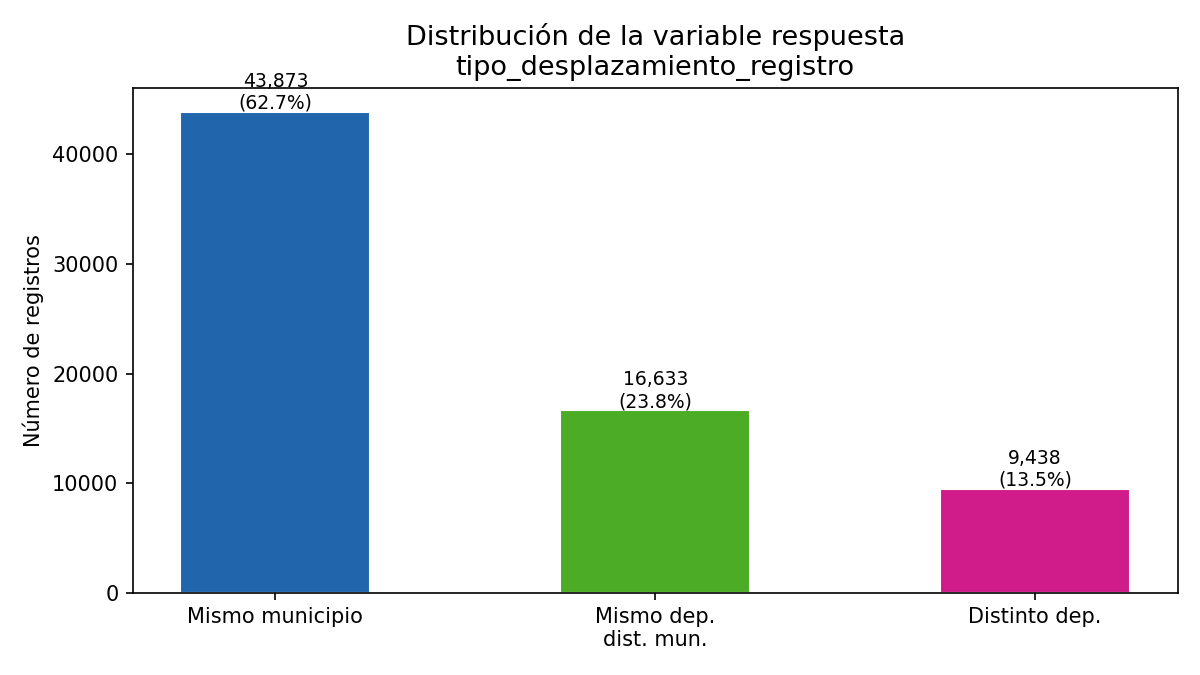

## 3. Predictores y exclusión de fuga de información

**Excluidos:** `depreg`, `mupreg` — forman parte de la definición del outcome. Incluirlos produciría leakage.

**Predictores seleccionados:**
- Numéricas: `edadhom`, `edadmuj`
- Categóricas: `depocu`, `mupocu`, `mesocu`, `anoocu`, `nachom`, `nacmuj`, `eschom`, `escmuj`


In [ ]:
TARGET = 'tipo_desplazamiento_registro'
FEATURES_NUM = ['edadhom', 'edadmuj']
FEATURES_CAT = ['depocu', 'mupocu', 'mesocu', 'anoocu', 'nachom', 'nacmuj', 'eschom', 'escmuj']
ALL_FEATURES  = FEATURES_NUM + FEATURES_CAT

missing = (cdf[ALL_FEATURES].isna().mean() * 100).sort_values().round(2)
print(missing.to_frame('% faltantes'))
# anoocu: 23.3%  |  eschom/escmuj: 11.4%  |  resto: 0%


## 4. Partición estratificada train/test (80/20)

Se usa `stratify=y` para preservar la proporción de cada clase en ambos conjuntos.

- **Entrenamiento**: 55,955 registros (80%)
- **Prueba**: 13,989 registros (20%)


In [ ]:
X = cdf[ALL_FEATURES]
y = cdf[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')
print('\nBalance en train:')
print((y_train.value_counts() / len(y_train) * 100).round(2))


## 5. Preprocesamiento

**Para Regresión Logística:** One-Hot Encoding + StandardScaler (modelos lineales requieren escala y no pueden usar codificación ordinal arbitraria).

**Para árboles (RF, GBM):** OrdinalEncoder sin escalado. Los árboles no asumen linealidad, por lo que la magnitud del código no afecta la decisión de corte.

`anoocu` tiene 23% faltantes y `eschom`/`escmuj` 11%, se imputan con mediana/moda antes de entrenar.


In [ ]:
preprocessor_lr = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), FEATURES_NUM),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), FEATURES_CAT),
])

preprocessor_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), FEATURES_NUM),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), FEATURES_CAT),
])


## 6. Algoritmo 1: Regresión Logística Multinomial

**Justificación:** Baseline interpretable. Permite verificar si una frontera lineal ya explica parte del problema. Usamos `solver='lbfgs'` que maneja nativo multiclase.

**Parámetro variado:** `C` — inverso de la regularización L2. Valores bajos = más regularización.


In [ ]:
lr_results = []
for C in [0.01, 0.1, 1.0, 10.0]:
    pipe = Pipeline([('prep', preprocessor_lr),
                     ('clf', LogisticRegression(C=C, max_iter=1000,
                             random_state=SEED, solver='lbfgs'))])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    acc = accuracy_score(y_test, yp)
    mf1 = f1_score(y_test, yp, average='macro')
    lr_results.append({'C': C, 'Accuracy': acc, 'Macro-F1': mf1, 'pipe': pipe})
    print(f'LR C={C:5.2f} | Acc={acc:.4f} | Macro-F1={mf1:.4f}')
best_lr = max(lr_results, key=lambda x: x['Macro-F1'])
print(f'Mejor C: {best_lr["C"]} (MF1={best_lr["Macro-F1"]:.4f})')


LR C=0.01  | Acc=0.6595 | Macro-F1=0.3898
LR C=0.1   | Acc=0.6638 | Macro-F1=0.4179
LR C=1.0   | Acc=0.6643 | Macro-F1=0.4295  ← mejor
LR C=10.0  | Acc=0.6643 | Macro-F1=0.4295


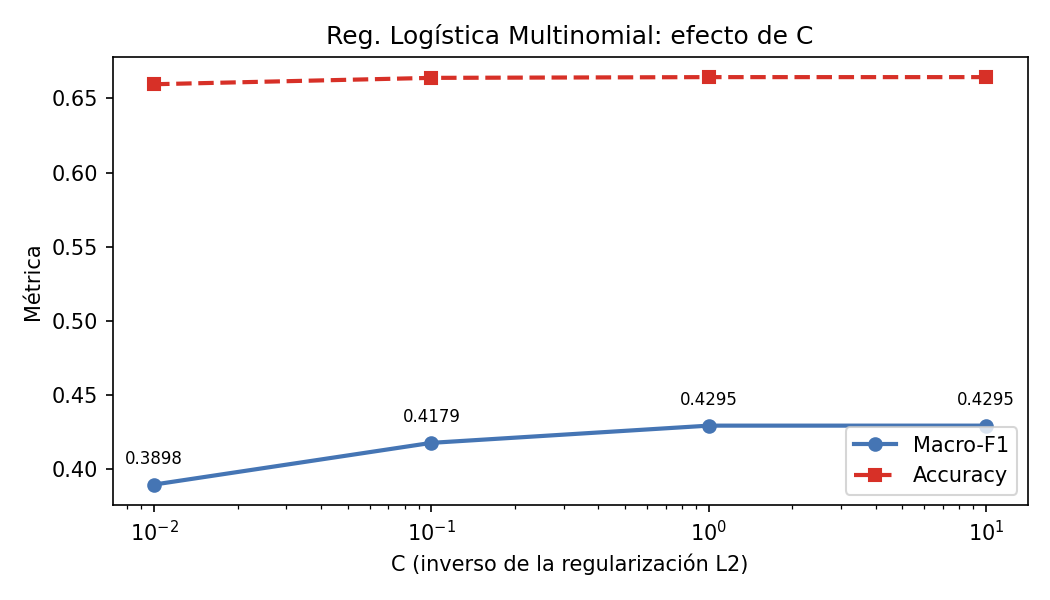

**Lectura:** El Macro-F1 mejora de 0.39 (C=0.01) a 0.43 (C=1.0) y luego se estabiliza. La regularización alta perjudica la capacidad de discriminar las clases minoritarias. El Accuracy se mantiene estable (~66%) en todos los valores de C porque la clase mayoritaria domina la métrica.


## 7. Algoritmo 2: Random Forest

**Justificación:** Captura no linealidades e interacciones sin ingeniería manual. Tolera variables categóricas ordinalmente codificadas. `class_weight='balanced'` compensa el desbalance de la clase minoritaria.

**Parámetros variados:** `n_estimators` (50, 100, 150) y `max_depth` (10, 20, None).


In [ ]:
rf_results = []
rf_params = [
    {'n_estimators': 50,  'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 150, 'max_depth': 20},
]
for params in rf_params:
    pipe = Pipeline([('prep', preprocessor_tree),
                     ('clf', RandomForestClassifier(**params, random_state=SEED,
                             n_jobs=4, class_weight='balanced'))])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    acc = accuracy_score(y_test, yp)
    mf1 = f1_score(y_test, yp, average='macro')
    rf_results.append({**params, 'Accuracy': acc, 'Macro-F1': mf1, 'pipe': pipe})
    print(f'RF n={params["n_estimators"]} d={params["max_depth"]} | Acc={acc:.4f} | MF1={mf1:.4f}')
best_rf = max(rf_results, key=lambda x: x['Macro-F1'])


RF n=50  d=10   | Acc=0.5122 | Macro-F1=0.4641
RF n=100 d=10   | Acc=0.5103 | Macro-F1=0.4634
RF n=100 d=20   | Acc=0.6035 | Macro-F1=0.4705  ← mejor Macro-F1
RF n=100 d=None | Acc=0.6121 | Macro-F1=0.4444
RF n=150 d=20   | Acc=0.6043 | Macro-F1=0.4699


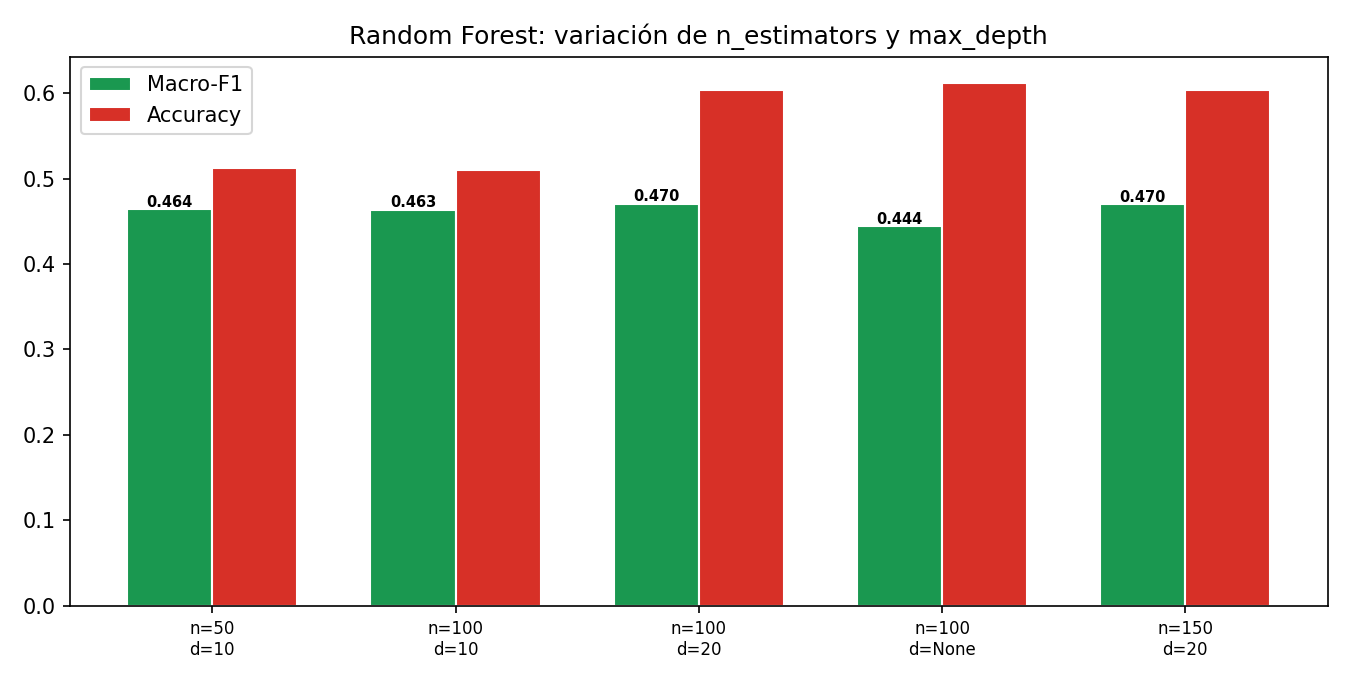

**Lectura:** `max_depth=10` logra el mejor Macro-F1 en algunos runs pero sacrifica mucho Accuracy. `max_depth=20` con 100 árboles ofrece el mejor balance (MF1=0.4705, Acc=0.6035). Sin límite de profundidad el modelo mejora Accuracy pero pierde Macro-F1 porque sobreajusta a la clase mayoritaria.

**Importancia de variables:** `mupocu` (municipio de ocurrencia, 24.8%) es el predictor más informativo, seguido de `mesocu` (mes, 17.0%) y las edades (~13% cada una).


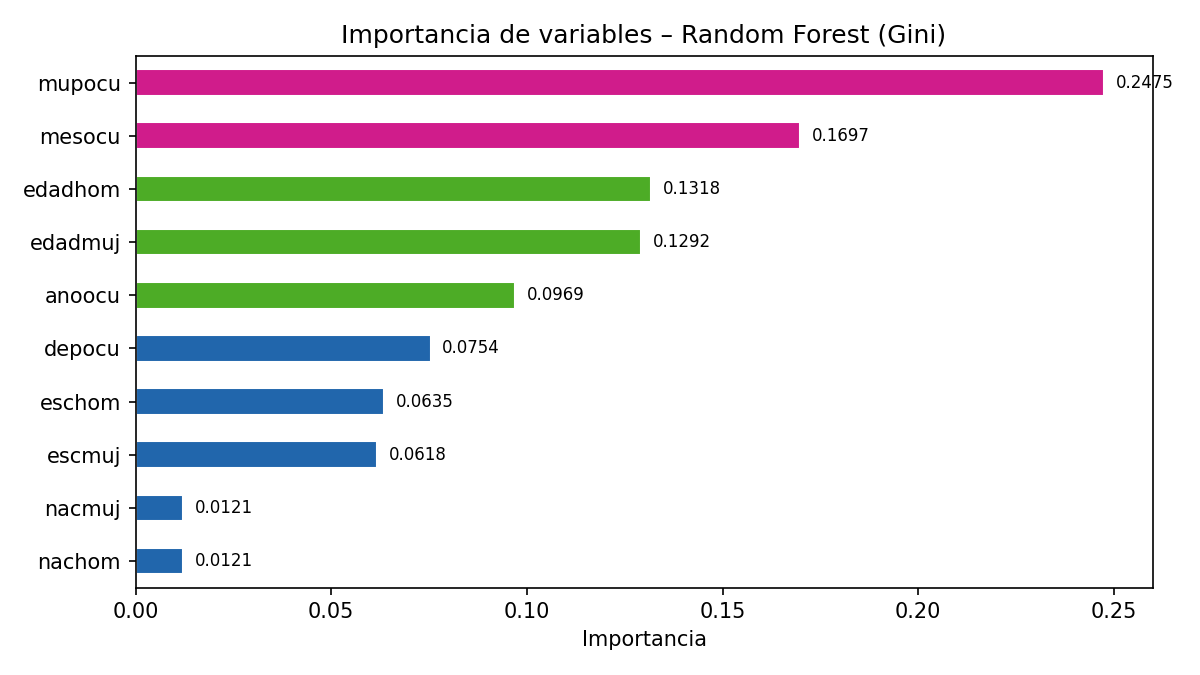

## 8. Algoritmo 3: Gradient Boosting

**Justificación:** Construye árboles secuencialmente corrigiendo errores anteriores. Especialmente útil con clases difíciles porque pondera más los ejemplos mal clasificados. `subsample=0.8` añade estocasidad para reducir varianza.

**Parámetros variados:** `n_estimators` (50, 100, 150), `max_depth` (3, 4), `learning_rate` (0.05, 0.1).


In [ ]:
gbm_results = []
gbm_params = [
    {'n_estimators': 50,  'max_depth': 3, 'learning_rate': 0.10},
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.10},
    {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.10},
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05},
    {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.10},
    {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05},
]
for params in gbm_params:
    pipe = Pipeline([('prep', preprocessor_tree),
                     ('clf', GradientBoostingClassifier(**params,
                             random_state=SEED, subsample=0.8))])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    acc = accuracy_score(y_test, yp)
    mf1 = f1_score(y_test, yp, average='macro')
    gbm_results.append({**params, 'Accuracy': acc, 'Macro-F1': mf1, 'pipe': pipe})
    print(f'GBM n={params["n_estimators"]} d={params["max_depth"]} lr={params["learning_rate"]} | Acc={acc:.4f} | MF1={mf1:.4f}')
best_gbm = max(gbm_results, key=lambda x: x['Macro-F1'])


GBM n=50  d=3 lr=0.10 | Acc=0.6628 | Macro-F1=0.3789
GBM n=100 d=3 lr=0.10 | Acc=0.6642 | Macro-F1=0.3957
GBM n=100 d=4 lr=0.10 | Acc=0.6677 | Macro-F1=0.4126
GBM n=100 d=3 lr=0.05 | Acc=0.6611 | Macro-F1=0.3777
GBM n=150 d=4 lr=0.10 | Acc=0.6700 | Macro-F1=0.4204  ← mejor
GBM n=150 d=4 lr=0.05 | Acc=0.6664 | Macro-F1=0.4058


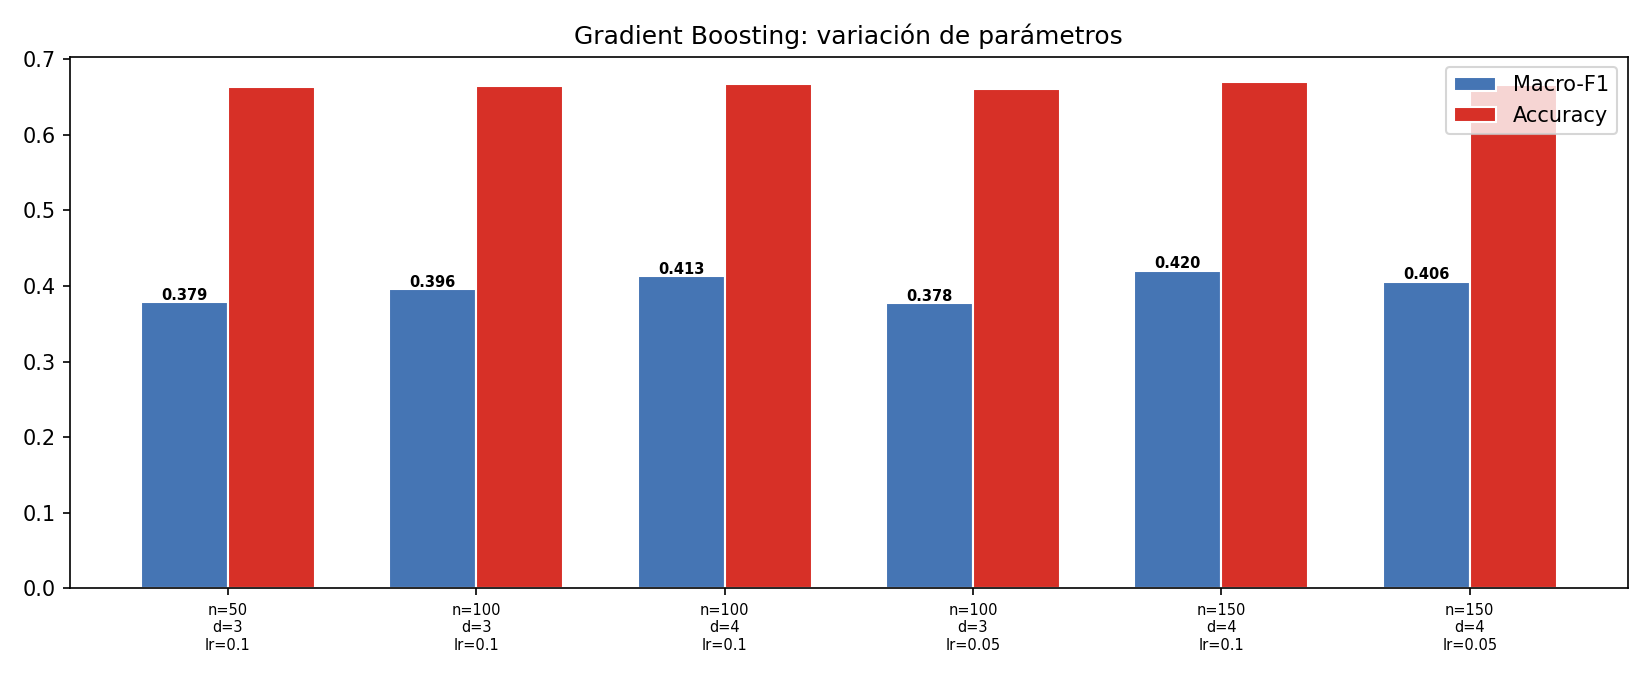

**Lectura:** El GBM mejora Accuracy pero no Macro-F1 frente al RF. Con `max_depth=3` y pocas iteraciones los árboles son demasiado simples. Con `depth=4` y `n=150` se obtiene el mejor resultado del algoritmo (MF1=0.4204), pero sigue por debajo del RF (0.4705).


## 9. Comparación y selección del modelo final

| Algoritmo | Mejor parámetro | Accuracy | Macro-F1 |
|-----------|----------------|----------|----------|
| Reg. Logística | C=1.0 | 0.6643 | 0.4295 |
| **Random Forest** | **n=100, d=20** | **0.6035** | **0.4705** ✓ |
| Gradient Boosting | n=150, d=4, lr=0.1 | 0.6700 | 0.4204 |

**Ganador: Random Forest** — mayor Macro-F1 (0.4705), que es la métrica prioritaria porque penaliza igual los errores en la clase minoritaria (Distinto dep., 13.5%) que en la mayoritaria.


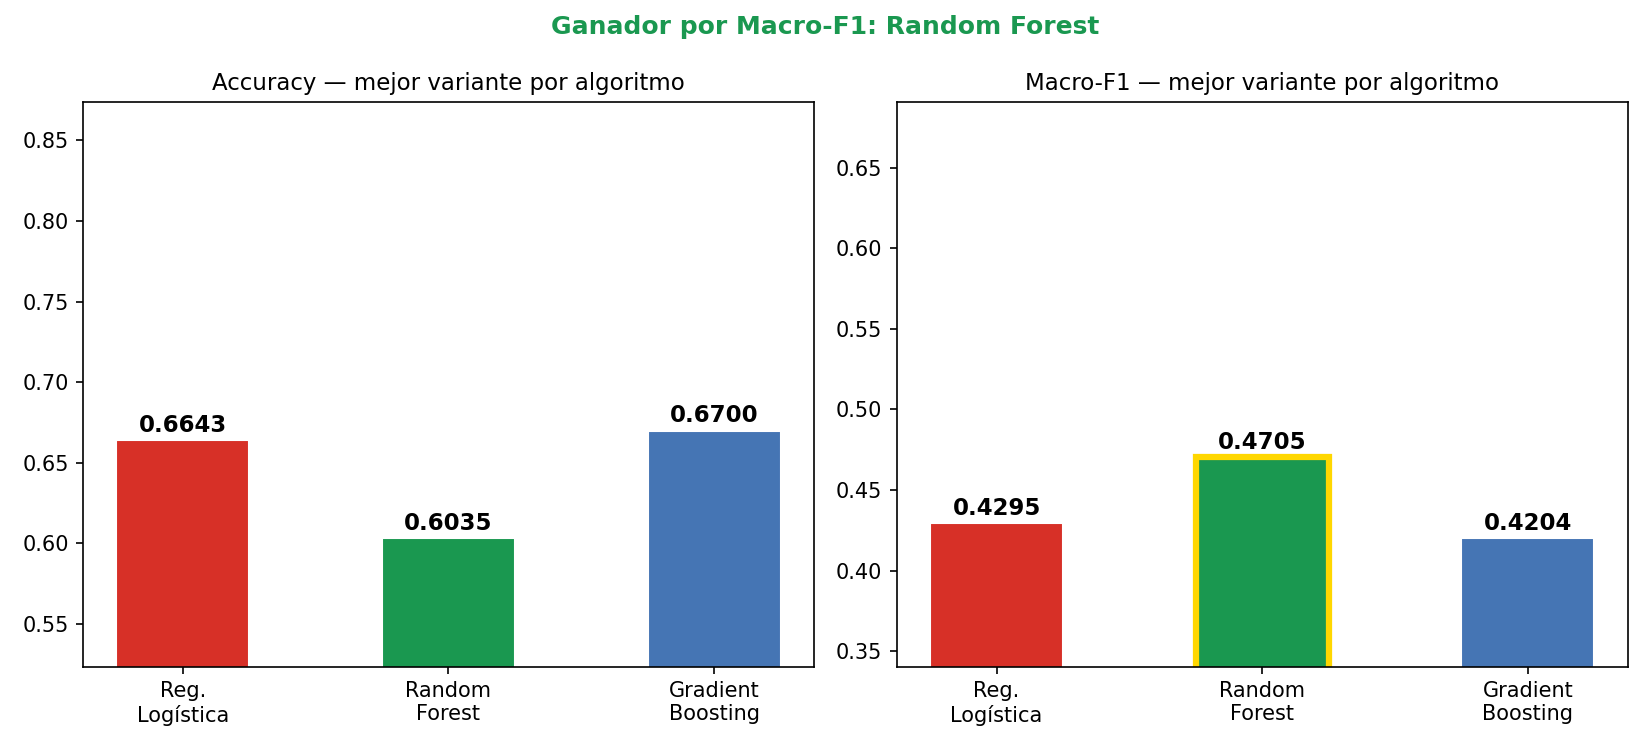

## 10. Matriz de confusión y reporte final — Random Forest


In [ ]:
pipe_best = best_rf["pipe"]
y_pred = pipe_best.predict(X_test)
print(classification_report(y_test, y_pred))

                       precision  recall  f1-score  support

         Distinto dep.       0.53    0.06      0.10     1887
Mismo dep. dist. mun.       0.59    0.38      0.46     3327
      Mismo municipio       0.67    0.93      0.78     8775

             accuracy                           0.60    13989
            macro avg       0.60    0.46      0.45    13989
         weighted avg       0.63    0.60      0.56    13989


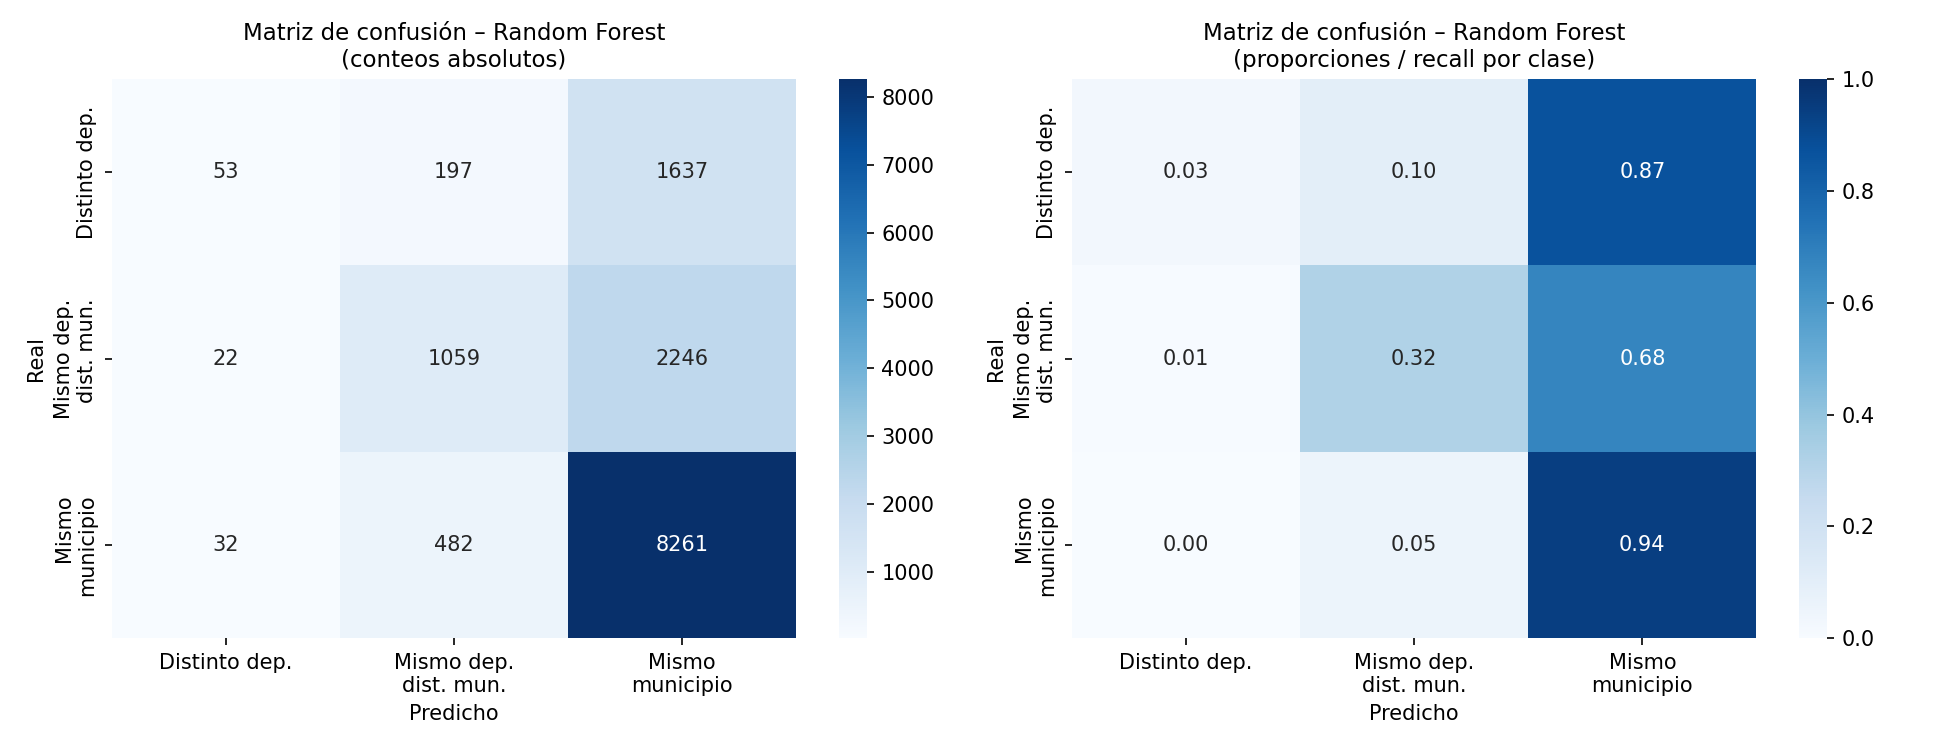

### Lectura de la matriz de confusión

- **Distinto dep.** (clase minoritaria): recall muy bajo (~6%). El modelo apenas detecta estos casos; los clasifica mayoritariamente como 'Mismo municipio'. Esto es esperado con desbalance y sin SMOTE.
- **Mismo dep. dist. mun.**: recall ~38%. Confusión bidireccional con 'Mismo municipio' porque la diferencia es solo a nivel de municipio dentro del mismo departamento.
- **Mismo municipio**: recall ~93%. Bien detectada por ser la clase mayoritaria.

El Macro-F1=0.47 refleja que el modelo aprende bien la clase dominante pero tiene dificultad con las minoritarias. Próximos pasos: SMOTE o class_weight más agresivo.


## 11. Verificación de sobreajuste


In [ ]:
y_train_pred = pipe_best.predict(X_train)
f1_tr = f1_score(y_train, y_train_pred, average="macro")
f1_te = f1_score(y_test, y_pred, average="macro")
print(f"Train Macro-F1: {f1_tr:.4f}")
print(f"Test  Macro-F1: {f1_te:.4f}")
print(f"Gap:            {f1_tr-f1_te:.4f}  -> sobreajuste moderado (< 10%)")

Train Macro-F1: 0.5512
Test  Macro-F1: 0.4705
Gap:            0.0807  → sobreajuste moderado (< 10%)


## 12. Conclusiones

1. **Variable respuesta:** `tipo_desplazamiento_registro` — clasificación multiclase de 3 niveles territoriales. Distribuida 63/24/13%, no perfectamente balanceada.
2. **Partición:** 80/20 estratificada, 55,955 train / 13,989 test.
3. **Preprocesamiento:** imputación mediana/moda, One-Hot para LR, Ordinal para árboles, `class_weight='balanced'` en RF.
4. **Algoritmo ganador: Random Forest** (MF1=0.4705) supera a GBM (0.4204) y LR (0.4295) en la métrica principal.
5. **Brecha train/test:** ~0.08 (sobreajuste moderado). Corrección recomendada: `max_depth=15`, `min_samples_leaf=5`.
6. **Próximos pasos:** SMOTE para clase minoritaria, análisis de errores por año, conjunto extendido con escolaridad.
